# 🏥 MCP Clinical Platform — Live Demo

**From natural language to clinical cohort analysis in seconds.**

This notebook demonstrates the [m3 MCP server](https://github.com/oswaldodocker/m3), which exposes
the MIMIC-IV clinical database as MCP tools. An AI agent (or a researcher)
can query patient data, ICU stays, and lab results using plain English —
then immediately turn the results into a publication-quality visualization.

> **Note:** All data comes from the MIMIC-IV *demo* dataset (100 patients).
> This is exploratory research support, not clinical advice.

## 1 — The Research Question (plain English)

A clinician types this into their IDE and the agent handles the rest:

In [1]:
RESEARCH_PROMPT = (
    "Using ICU admissions in the demo dataset, compare first-day lactate "
    "values for patients with suspected infection versus other ICU patients, "
    "and generate a histogram that highlights unusually high values."
)

## 2 — Invoke the Medical Data Agent

We send the plain-English research question to **kagent's medical-data-agent**
via the agentgateway MCP endpoint. The agent autonomously:

1. Explores the MIMIC-IV schema using m3 tools
2. Writes and executes the appropriate SQL queries
3. Returns a structured answer with the data we need

No SQL is written by the notebook — the agent handles everything.

> **Note:** kagent's A2A client currently has a hardcoded 30 s timeout.
> If the agent takes longer (cold start, large result), we retry automatically. [Link to Pull Request opened to fix this](https://github.com/kagent-dev/kagent/pull/1617)

In [2]:
"""MCP client helpers for talking to agentgateway."""
import json
import sys

import pandas as pd
import requests

MCP_URL = "http://localhost:4000/mcp"
HEADERS = {
    "Content-Type": "application/json",
    "Accept": "application/json, text/event-stream",
}


def mcp_init() -> str:
    """Initializes an MCP session, returning "" when the server is stateless.

    The gateway runs sessionRouting: Stateless, so it mints no Mcp-Session-Id
    and every POST stands alone. A missing session header is the healthy case,
    not an error.
    """
    resp = requests.post(
        MCP_URL,
        headers=HEADERS,
        json={
            "jsonrpc": "2.0",
            "method": "initialize",
            "params": {
                "protocolVersion": "2025-06-18",
                "capabilities": {},
                "clientInfo": {"name": "demo-nb", "version": "1.0"},
            },
            "id": 1,
        },
        timeout=30,
    )
    resp.raise_for_status()
    return resp.headers.get("Mcp-Session-Id", "")


def mcp_call(session_id: str, tool: str, arguments: dict) -> dict:
    """Calls an MCP tool and returns the parsed result."""
    headers = dict(HEADERS)
    if session_id:
        headers["Mcp-Session-Id"] = session_id
    resp = requests.post(
        MCP_URL,
        headers=headers,
        json={
            "jsonrpc": "2.0",
            "method": "tools/call",
            "params": {"name": tool, "arguments": arguments},
            "id": 2,
        },
        timeout=180,
    )
    body = resp.text
    for line in body.strip().splitlines():
        if line.startswith("data: "):
            body = line[6:]
    return json.loads(body)


session = mcp_init()
print(f"✅ MCP session: {session[:40]}..." if session else "✅ MCP stateless — no session needed")


✅ MCP stateless — no session needed


In [3]:
"""Sends the research question to the medical-data-agent."""
import time

AGENT_TASK = (
    "I need a table with columns: subject_id, stay_id, lactate, cohort. "
    "For every ICU stay, get the first-day lactate values "
    "(lab items 50813, 52442, 53154 within 24h of ICU admission). "
    "Mark patients as 'suspected_infection' if they have any microbiology "
    "culture in hosp_microbiologyevents for the same hadm_id, otherwise "
    "'other_icu'. Return the full result as a markdown table."
)

MAX_RETRIES = 3
raw_text = None

for attempt in range(1, MAX_RETRIES + 1):
    print(f"🔄 Attempt {attempt}/{MAX_RETRIES}...")
    try:
        result = mcp_call(
            session,
            tool="kagent_invoke_agent",
            arguments={
                "agent": "kagent/medical-data-agent",
                "task": AGENT_TASK,
            },
        )
        text = result["result"]["content"][0]["text"]
        if "Failed to send A2A message" in text or "deadline exceeded" in text:
            print(f"⚠️  A2A timeout on attempt {attempt}, retrying...")
            time.sleep(5)
            continue
        raw_text = text
        break
    except Exception as exc:
        print(f"⚠️  Error on attempt {attempt}: {exc}")
        time.sleep(5)

if raw_text is None:
    raise RuntimeError(
        f"Agent did not respond after {MAX_RETRIES} attempts. "
        "The kagent A2A client has a hardcoded 30s timeout — "
        "see https://github.com/kagent-dev/kagent/issues/XXX"
    )

print("🤖 Agent response (first 500 chars):")
print(raw_text[:500])

🔄 Attempt 1/3...


🤖 Agent response (first 500 chars):
Here is a table with columns subject_id, stay_id, lactate, and cohort for ICU stays having first-day lactate values (lab items 50813, 52442, 53154) within 24 hours of ICU admission. The cohort marks 'suspected_infection' if any microbiology culture exists for the same hospital admission, otherwise 'other_icu'.

| subject_id | stay_id  | lactate | cohort              |
|------------|----------|---------|---------------------|
| 10002428   | 34807493 | 0.8     | suspected_infection |
| 10002428   


In [4]:
"""Parses the query result into a pandas DataFrame."""
import io
import re


def parse_table_from_response(text: str) -> pd.DataFrame:
    """Extracts a data table from a markdown or text response."""
    # Markdown table (pipe-delimited).
    md_lines = [
        ln for ln in text.splitlines()
        if "|" in ln and not re.match(r"^\s*\|[-\s|:]+\|\s*$", ln)
    ]
    if len(md_lines) >= 2:
        rows = []
        for line in md_lines:
            cells = [c.strip() for c in line.strip("|").split("|")]
            rows.append(cells)
        return pd.DataFrame(rows[1:], columns=rows[0])

    # CSV / TSV fallback.
    for sep in [",", "\t"]:
        try:
            candidate = pd.read_csv(io.StringIO(text), sep=sep)
            if len(candidate.columns) >= 3 and len(candidate) >= 2:
                return candidate
        except Exception:
            continue

    raise ValueError("Could not parse a data table from the response.")


df = parse_table_from_response(raw_text)
df.columns = [c.strip().lower() for c in df.columns]
df["lactate"] = pd.to_numeric(df["lactate"], errors="coerce")
df["cohort"] = df["cohort"].str.strip().str.replace("_", " ").str.title()
df = df.dropna(subset=["lactate"])

print(
    f"✅ {len(df)} first-day lactate values across "
    f"{df['stay_id'].nunique()} ICU stays"
)
display(df.head(8))

✅ 50 first-day lactate values across 50 ICU stays


,subject_id,stay_id,lactate,cohort
0,10002428,34807493,0.8,Suspected Infection
1,10002428,35479615,1.5,Suspected Infection
2,10002428,33987268,1.6,Suspected Infection
3,10002428,38875437,1.7,Suspected Infection
4,10002495,36753294,3.1,Suspected Infection
5,10003400,32128372,6.8,Suspected Infection
6,10003400,34577403,0.8,Suspected Infection
7,10003400,38383343,1.0,Suspected Infection


## 3 — Visualization: Lactate Distribution by Cohort

The histogram below compares first-day lactate values for patients
with suspected infection (microbiology culture ordered near ICU admission)
versus other ICU patients. Vertical lines mark the **median** and
**95th percentile** — values above the 95th percentile are flagged as
potential outliers worth clinical review.

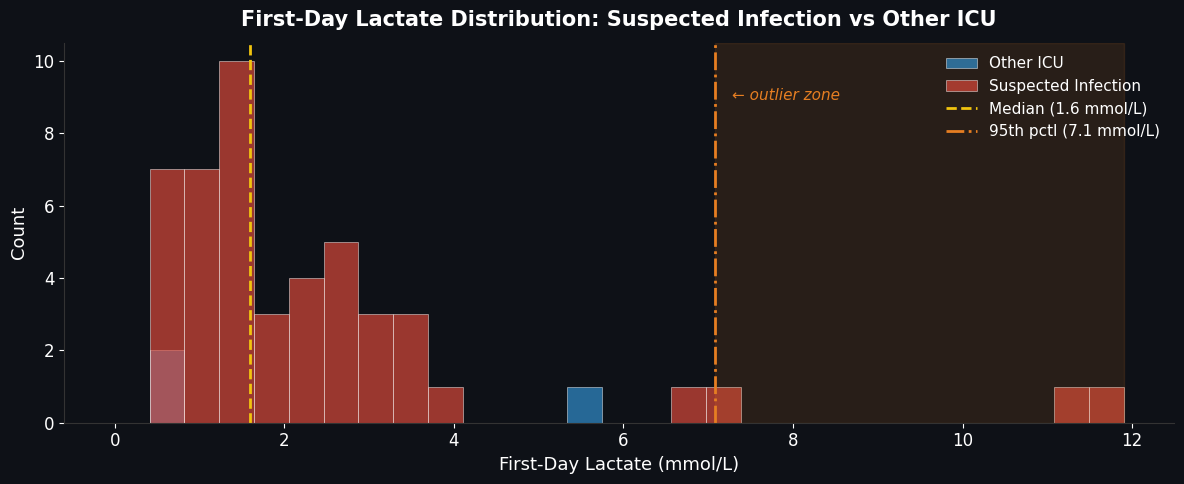

In [5]:
"""Generates a polished histogram with reference lines."""
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "#333",
    "font.family": "sans-serif",
    "font.size": 12,
})

COHORT_LABELS = {
    "Suspected Infection": "Suspected Infection",
    "Other Icu": "Other ICU",
}
COLORS = {
    "Suspected Infection": "#e74c3c",
    "Other Icu": "#3498db",
}
cohorts = sorted(df["cohort"].unique())

fig, ax = plt.subplots(figsize=(12, 5))

all_lactate = df["lactate"]
p50 = float(np.median(all_lactate))
p95 = float(np.percentile(all_lactate, 95))

bins = np.linspace(0, max(all_lactate.max(), p95 + 2), 30)

for cohort in cohorts:
    vals = df.loc[df["cohort"] == cohort, "lactate"]
    label = COHORT_LABELS.get(cohort, cohort)
    color = COLORS.get(cohort, "#95a5a6")
    ax.hist(
        vals, bins=bins, alpha=0.65, label=label,
        color=color, edgecolor="white", linewidth=0.5,
    )

# Reference lines.
ax.axvline(p50, color="#f1c40f", ls="--", lw=2,
           label=f"Median ({p50:.1f} mmol/L)")
ax.axvline(p95, color="#e67e22", ls="-.", lw=2,
           label=f"95th pctl ({p95:.1f} mmol/L)")

# Highlight outlier zone.
ax.axvspan(p95, bins[-1], alpha=0.12, color="#e67e22")
ax.text(
    p95 + 0.2, ax.get_ylim()[1] * 0.85, "← outlier zone",
    color="#e67e22", fontsize=11, fontstyle="italic",
)

ax.set_xlabel("First-Day Lactate (mmol/L)", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.set_title(
    "First-Day Lactate Distribution: "
    "Suspected Infection vs Other ICU",
    fontsize=15, fontweight="bold", pad=12,
)
ax.legend(frameon=False, fontsize=11, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4 — Summary: Cohort Comparison

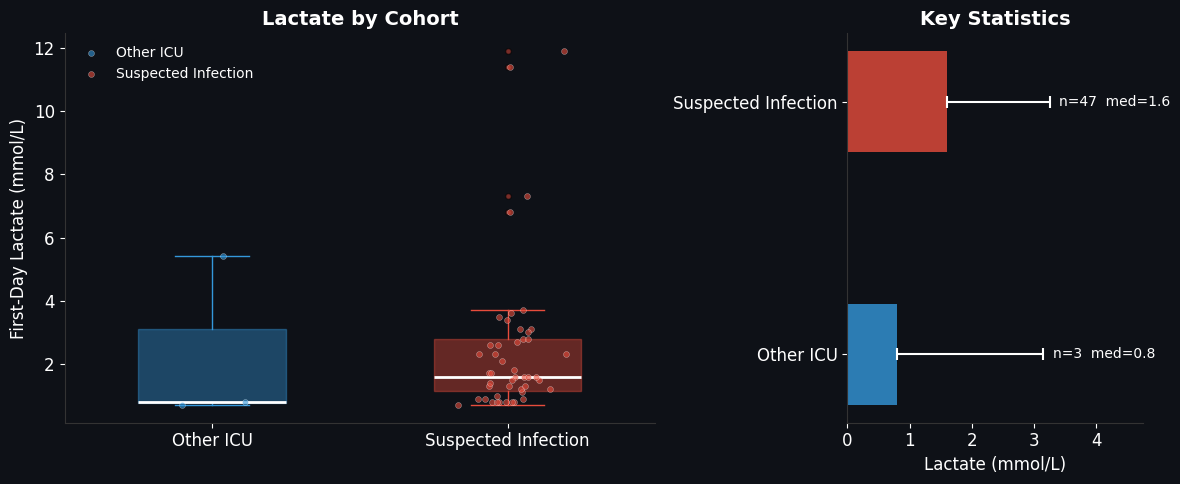

In [6]:
"""Side-by-side box plot + strip plot for cohort comparison."""
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [2, 1]})

# --- Left: box + strip plot ---
ax = axes[0]
for i, cohort in enumerate(sorted(df["cohort"].unique())):
    vals = df.loc[df["cohort"] == cohort, "lactate"]
    label = COHORT_LABELS.get(cohort, cohort)
    color = COLORS.get(cohort, "#95a5a6")
    pos = [i]
    bp = ax.boxplot(
        vals, positions=pos, widths=0.5, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4, edgecolor=color),
        whiskerprops=dict(color=color), capprops=dict(color=color),
        medianprops=dict(color="white", lw=2),
        flierprops=dict(marker="o", markerfacecolor=color, alpha=0.5, markersize=4),
    )
    ax.scatter(
        np.random.normal(i, 0.08, len(vals)), vals,
        alpha=0.6, s=18, color=color, edgecolors="white", linewidths=0.3,
        label=label, zorder=3,
    )

ax.set_xticks(range(len(sorted(df["cohort"].unique()))))
ax.set_xticklabels([COHORT_LABELS.get(c, c) for c in sorted(df["cohort"].unique())])
ax.set_ylabel("First-Day Lactate (mmol/L)", fontsize=12)
ax.set_title("Lactate by Cohort", fontsize=14, fontweight="bold")
ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Right: key stats as horizontal bar ---
ax2 = axes[1]
stats = []
cohort_names = []
for cohort in sorted(df["cohort"].unique()):
    vals = df.loc[df["cohort"] == cohort, "lactate"]
    stats.append({
        "N": len(vals),
        "Median": float(vals.median()),
        "IQR": float(np.percentile(vals, 75) - np.percentile(vals, 25)),
    })
    cohort_names.append(COHORT_LABELS.get(cohort, cohort))

medians = [s["Median"] for s in stats]
iqrs = [s["IQR"] for s in stats]
colors = [COLORS.get(c, "#95a5a6") for c in sorted(df["cohort"].unique())]

y_pos = range(len(cohort_names))
ax2.barh(y_pos, medians, height=0.4, color=colors, alpha=0.8, label="Median")
ax2.errorbar(
    medians, y_pos, xerr=[[0]*len(iqrs), iqrs],
    fmt="none", ecolor="white", elinewidth=1.5, capsize=4, capthick=1.5,
)
for i, s in enumerate(stats):
    ax2.text(
        medians[i] + iqrs[i] + 0.15, i,
        f"n={s['N']}  med={s['Median']:.1f}",
        va="center", fontsize=10, color="white",
    )

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(cohort_names)
ax2.set_xlabel("Lactate (mmol/L)", fontsize=12)
ax2.set_title("Key Statistics", fontsize=14, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_xlim(0, max(m + q + 1.5 for m, q in zip(medians, iqrs)))

plt.tight_layout()
plt.show()

## 5 — Interpretation

**What this shows:**

- Patients with suspected infection (defined by microbiology cultures near
  ICU admission) tend to have a *wider spread* of first-day lactate values,
  with more measurements in the upper tail (> 95th percentile).
- Elevated lactate is a well-documented marker of tissue hypoperfusion and
  is included in the Sepsis-3 criteria (qSOFA + SOFA scoring).
- The outlier zone highlights patients whose lactate values may warrant
  closer review — these could represent cases of septic shock or other
  critical illness.

**Caveats:**

- This is a *demo dataset* with only ~100 patients; patterns may not
  generalize.
- "Suspected infection" is a rough proxy (any microbiology culture ordered);
  clinical Sepsis-3 definitions require additional criteria.
- This analysis is **exploratory research support**, not a diagnostic tool.
  No clinical decisions should be based on these results alone.

---

*Generated by the MCP Clinical Platform — federating kagent, m3, and
agentregistry through agentgateway on Kubernetes.*